In [4]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
from tensorflow.keras.models import Model
import nibabel as nib
import os 


def global_normalized_cross_correlation_loss():
    def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat,
                                             axis=range(1, ndim+1)))
    return ncc


def local_normalized_cross_correlation_loss(window=(6, 6, 6), eps=1e-5):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/src/losses.py#L28
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def ncc(I, J, window=window):
        # get dimension of volume
        # assumes I, J are sized [batch_size, *vol_shape, nb_feats]
        # ndims = len(I.get_shape().as_list()) - 2
        ndims = tf.keras.backend.ndim(I)-2
        assert ndims in [1, 2, 3], "volumes should be 1 to 3 dimensions. found: %d" % ndims

        # set window size
        if window is None:
            window = [9] * ndims

        # get convolution function
        conv_fn = getattr(tf.nn, 'conv%dd' % ndims)

        # compute CC squares
        I2 = I*I
        J2 = J*J
        IJ = I*J

        # compute filters
        sum_filt = tf.ones([*window, 1, 1])
        strides = [1] * (ndims + 2)
        padding = 'SAME'

        # compute local sums via convolution
        I_sum = conv_fn(I, sum_filt, strides, padding)
        J_sum = conv_fn(J, sum_filt, strides, padding)
        I2_sum = conv_fn(I2, sum_filt, strides, padding)
        J2_sum = conv_fn(J2, sum_filt, strides, padding)
        IJ_sum = conv_fn(IJ, sum_filt, strides, padding)

        # compute cross correlation
        win_size = np.prod(window)
        u_I = I_sum/win_size
        u_J = J_sum/win_size

        cross = IJ_sum - u_J*I_sum - u_I*J_sum + u_I*u_J*win_size
        I_var = I2_sum - 2 * u_I * I_sum + u_I*u_I*win_size
        J_var = J2_sum - 2 * u_J * J_sum + u_J*u_J*win_size

        cc = cross*cross / (I_var*J_var + eps)

        # return negative cc.
        return -tf.reduce_mean(cc)
    return ncc

# vein. Portal veins are well enhanced and some enhancement of the hepatic veins is also seen on the portal venous phase. T
def gradient_loss(norm=2):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/pytorch/losses.py#L13
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def grad_loss(_, phi):
        di = tf.abs(phi[:, 1:, :, :, :] - phi[:, :-1, :, :, :])
        dj = tf.abs(phi[:, :, 1:, :, :] - phi[:, :, :-1, :, :])
        dk = tf.abs(phi[:, :, :, 1:, :] - phi[:, :, :, :-1, :])

        loss = tf.reduce_mean(di) + tf.reduce_mean(dj) + tf.reduce_mean(dk)
        if norm == 2:
            loss = tf.reduce_mean(di**2) + tf.reduce_mean(dj**2) + tf.reduce_mean(dk**2)    
        return loss
    return grad_loss

def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved

class AffineNet(object):
    def __init__(self, input_shape=(128, 128, 64), optimizer='adam', loss=None,
                 metrics=None, loss_weights=None):
        in_channels = 1
        out_channels = 3
        d, h, w = input_shape
        input_shape = input_shape + (in_channels,)
        moving = layers.Input(shape=input_shape, name='moving')
        static = layers.Input(shape=input_shape, name='static')
        
        
        x_in = layers.concatenate([static, moving], axis=-1)

        # encoder
        x1 = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x_in)
        x1 = layers.LeakyReLU(alpha=0.2)(x1)  # 16
        x1 = layers.BatchNormalization()(x1)      

        x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x1)
        x2 = layers.LeakyReLU(alpha=0.2)(x2)  # 8
        x2 = layers.BatchNormalization()(x2)      

        x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x2)
        x3 = layers.LeakyReLU(alpha=0.2)(x3)  # 4
        x3 = layers.BatchNormalization()(x3)      

        x4 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x3)
        x4 = layers.LeakyReLU(alpha=0.2)(x4)  # 2 # 4 for 64
        x4 = layers.BatchNormalization()(x4)      

        s = 1.0  # scaling
        t = 0  # translation
        x = layers.Flatten()(x4)
        x = layers.Dense(64, activation='relu')(x)  # 4*4*32
        x = layers.Dense(12, kernel_initializer='zeros',
                         bias_initializer=tf.constant_initializer([s,0,0,t,0,s,0,t,0,0,s,t]), name='theta')(x)
        
        
        nb, _ = tf.shape(x)
        self.theta = tf.reshape(x, [nb, 3, 4])
        grid = regular_grid_3d(d, h, w)
        grid_new = grid_transform_3d(self.theta, grid)
        grid_new = tf.clip_by_value(grid_new, -1, 1)

        moved = grid_sample_3d(moving, grid_new, name='moved')

        model = tf.keras.Model(inputs={'moving': moving, 'static': static},
                                outputs={'moved': moved}, name='AffineNet')
        
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                      loss_weights=loss_weights)
        
        self.model = model
        
#     def theta_get(self):
#         return model.get_layer('theta')

    def compile(self, optimizer='adam', loss=None, metrics=None,
                loss_weights=None):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                           loss_weights=loss_weights)

    def summary(self):
        return self.model.summary()

    def fit(self, x=None, y=None, batch_size=None, epochs=1, verbose=1,
            callbacks=None, validation_split=0.0, validation_data=None,
            shuffle=True, initial_epoch=0, steps_per_epoch=None,
            validation_steps=None, validation_batch_size=None,
            validation_freq=1, max_queue_size=10, workers=1,
            use_multiprocessing=False):
        return self.model.fit(x=x, y=y, batch_size=batch_size,
                              epochs=epochs, verbose=verbose,
                              callbacks=callbacks,
                              validation_split=validation_split,
                              validation_data=validation_data, shuffle=shuffle,
                              initial_epoch=initial_epoch,
                              steps_per_epoch=steps_per_epoch,
                              validation_steps=validation_steps,
                              validation_batch_size=validation_batch_size,
                              validation_freq=validation_freq,
                              max_queue_size=max_queue_size, workers=workers,
                              use_multiprocessing=use_multiprocessing)

    def evaluate(self, x=None, y=None, batch_size=None, verbose=1,
                 steps=None, callbacks=None, max_queue_size=10, workers=1,
                 use_multiprocessing=False, return_dict=False):
        return self.model.evaluate(x=x, y=y, batch_size=batch_size,
                                   verbose=verbose, steps=steps,
                                   callbacks=callbacks,
                                   max_queue_size=max_queue_size,
                                   workers=workers,
                                   use_multiprocessing=use_multiprocessing,
                                   return_dict=return_dict)
    
    def predict(self, x, batch_size=None, verbose=0,
                steps=None, callbacks=None, max_queue_size=10, workers=1,
                use_multiprocessing=False):
        return self.model.predict(x=x, batch_size=batch_size,
                                  verbose=verbose, steps=steps,
                                  callbacks=callbacks,
                                  max_queue_size=max_queue_size,
                                  workers=workers,
                                  use_multiprocessing=use_multiprocessing)
    def save_weights(self, filepath, overwrite=True):
        self.model.save_weights(filepath=filepath, overwrite=overwrite, save_format=None)

    def load_weights(self, filepath):
        self.model.load_weights(filepath)
    
        
#     def get_theta(self):
#         return self.theta
        
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.

        """
        self.moving = moving
        self.static = static
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)

        return {'moving': moving, 'static': static}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)

In [2]:
def grid_transform_3d(theta, grid):
    nb = tf.shape(theta)[0]
    nd, nh, nw, _ = tf.shape(grid)

    i = grid[..., 0] # d, h, w
    j = grid[..., 1]
    k = grid[..., 2]

    i_flat = tf.reshape(i, shape=[-1])
    j_flat = tf.reshape(j, shape=[-1])
    k_flat = tf.reshape(k, shape=[-1])

    ones = tf.ones_like(i_flat)

    grid_flat = tf.stack([i_flat, j_flat, k_flat, ones])
    grid_flat = tf.expand_dims(grid_flat, axis=0)
    grid_flat = tf.tile(grid_flat, tf.stack([nb, 1, 1]))  # n, 4, d*h*w

    # 2d 2x3; 3d 3x4
    theta = tf.cast(theta, 'float32')
    grid_flat = tf.cast(grid_flat, 'float32')
    grid_new = tf.matmul(theta, grid_flat)  # n, 3, d*h*w
    
    grid_new = tf.transpose(grid_new, perm=[0,2,1])
    grid_new = tf.reshape(grid_new, [nb, nd, nh, nw, 3])

    return grid_new

In [3]:
batch_size = 4
epochs = 500
lr = 0.001  # learning rate
lamda = 0.2  # (lambda) regularization parameter
input_shape = (64, 128, 128)

In [4]:
# 0~1 사이로 정규화 
import nibabel as nib
import os 

# filename = "./mix_data/mixed_affine.nii.gz"
# filename2 = "./static_data_exis/7.nii.gz"
filename = "./BTCV_Data/resize_exis_stack.nii.gz"
filename2 = "./BTCV_Data/static_exis/40.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)

-3024.0
3095.0


In [5]:
# print(data[0].shape)

# a = data[0]
# print(a.shape)
# a = a.swapaxes(0,2) 

# print(a.shape)
# a = nib.Nifti1Image(a,None) 

# nib.save(a,'./chaos_train_voxel/test.nii.gz')

In [6]:
x_train = data[:26, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[26:, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = data[0:, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)

train_loader = RegistrationDataLoader(x_train, static, batch_size=batch_size,
                                      shuffle=True)
test_loader = RegistrationDataLoader(x_test, static, batch_size=batch_size,
                                     shuffle=True)
sample_loader = RegistrationDataLoader(x_sample, static, shuffle=False)

Train:  (26, 64, 128, 128, 1)
Test:  (3, 64, 128, 128, 1)
Sample:  (29, 64, 128, 128)
Static:  (1, 64, 128, 128, 1)


In [7]:
ncc_loss = global_normalized_cross_correlation_loss()
grad_loss = gradient_loss()

# Map model outputs to the loss functions and loss weights
loss_weights = {'moved': 1.0}
losses = {'moved': ncc_loss}

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model = AffineNet(input_shape=input_shape, optimizer=optimizer,
                    loss=losses, loss_weights=loss_weights)

In [9]:
import tensorflow

early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=250, restore_best_weights=True) 
checkpoint_path = "./Affinecheck/0630_cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

Epoch 1/500
7/7 [==============================] - ETA: 0s - loss: -0.5456
Epoch 00001: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 334ms/step - loss: -0.5456 - val_loss: -0.5563
Epoch 2/500
7/7 [==============================] - ETA: 0s - loss: -0.5423
Epoch 00002: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 280ms/step - loss: -0.5423 - val_loss: -0.5385
Epoch 3/500
7/7 [==============================] - ETA: 0s - loss: -0.5228
Epoch 00003: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 280ms/step - loss: -0.5228 - val_loss: -0.5508
Epoch 4/500
7/7 [==============================] - ETA: 0s - loss: -0.5358
Epoch 00004: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 279ms/step - loss: -0.5358 - val_loss: -0.5315
Epoch 5/500
7/7 [==============================] - ETA: 0s - loss: -0.5219
Epoch 00005: saving model to ./Affinecheck/06

7/7 [==============================] - ETA: 0s - loss: -0.7041
Epoch 00075: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 287ms/step - loss: -0.7041 - val_loss: -0.6716
Epoch 76/500
7/7 [==============================] - ETA: 0s - loss: -0.6926
Epoch 00076: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 282ms/step - loss: -0.6926 - val_loss: -0.6450
Epoch 77/500
7/7 [==============================] - ETA: 0s - loss: -0.6941
Epoch 00077: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 281ms/step - loss: -0.6941 - val_loss: -0.6831
Epoch 78/500
7/7 [==============================] - ETA: 0s - loss: -0.6962
Epoch 00078: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 294ms/step - loss: -0.6962 - val_loss: -0.6627
Epoch 79/500
7/7 [==============================] - ETA: 0s - loss: -0.6894
Epoch 00079: saving model to ./Affinecheck/0630_cp.ck

Epoch 149/500
7/7 [==============================] - ETA: 0s - loss: -0.7050
Epoch 00149: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 287ms/step - loss: -0.7050 - val_loss: -0.6774
Epoch 150/500
7/7 [==============================] - ETA: 0s - loss: -0.7071
Epoch 00150: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 280ms/step - loss: -0.7071 - val_loss: -0.6631
Epoch 151/500
7/7 [==============================] - ETA: 0s - loss: -0.7028
Epoch 00151: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 282ms/step - loss: -0.7028 - val_loss: -0.6565
Epoch 152/500
7/7 [==============================] - ETA: 0s - loss: -0.7063
Epoch 00152: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 286ms/step - loss: -0.7063 - val_loss: -0.6591
Epoch 153/500
7/7 [==============================] - ETA: 0s - loss: -0.7049
Epoch 00153: saving model to ./Affi

Epoch 186/500
7/7 [==============================] - ETA: 0s - loss: -0.6901
Epoch 00186: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 289ms/step - loss: -0.6901 - val_loss: -0.6642
Epoch 187/500
7/7 [==============================] - ETA: 0s - loss: -0.7045
Epoch 00187: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 274ms/step - loss: -0.7045 - val_loss: -0.6656
Epoch 188/500
7/7 [==============================] - ETA: 0s - loss: -0.6945
Epoch 00188: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 287ms/step - loss: -0.6945 - val_loss: -0.6515
Epoch 189/500
7/7 [==============================] - ETA: 0s - loss: -0.6967
Epoch 00189: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 291ms/step - loss: -0.6967 - val_loss: -0.6561
Epoch 190/500
7/7 [==============================] - ETA: 0s - loss: -0.6972
Epoch 00190: saving model to ./Affi

Epoch 223/500
7/7 [==============================] - ETA: 0s - loss: -0.7055
Epoch 00223: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 292ms/step - loss: -0.7055 - val_loss: -0.6595
Epoch 224/500
7/7 [==============================] - ETA: 0s - loss: -0.6857
Epoch 00224: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 280ms/step - loss: -0.6857 - val_loss: -0.6601
Epoch 225/500
7/7 [==============================] - ETA: 0s - loss: -0.6927
Epoch 00225: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 275ms/step - loss: -0.6927 - val_loss: -0.6672
Epoch 226/500
7/7 [==============================] - ETA: 0s - loss: -0.6913
Epoch 00226: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 279ms/step - loss: -0.6913 - val_loss: -0.6712
Epoch 227/500
7/7 [==============================] - ETA: 0s - loss: -0.7046
Epoch 00227: saving model to ./Affi

Epoch 260/500
7/7 [==============================] - ETA: 0s - loss: -0.7005
Epoch 00260: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 280ms/step - loss: -0.7005 - val_loss: -0.6741
Epoch 261/500
7/7 [==============================] - ETA: 0s - loss: -0.7087
Epoch 00261: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 282ms/step - loss: -0.7087 - val_loss: -0.6792
Epoch 262/500
7/7 [==============================] - ETA: 0s - loss: -0.6995
Epoch 00262: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 278ms/step - loss: -0.6995 - val_loss: -0.6704
Epoch 263/500
7/7 [==============================] - ETA: 0s - loss: -0.7101
Epoch 00263: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 279ms/step - loss: -0.7101 - val_loss: -0.6528
Epoch 264/500
7/7 [==============================] - ETA: 0s - loss: -0.6982
Epoch 00264: saving model to ./Affi

Epoch 297/500
7/7 [==============================] - ETA: 0s - loss: -0.6925
Epoch 00297: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 282ms/step - loss: -0.6925 - val_loss: -0.6933
Epoch 298/500
7/7 [==============================] - ETA: 0s - loss: -0.7136
Epoch 00298: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 284ms/step - loss: -0.7136 - val_loss: -0.6708
Epoch 299/500
7/7 [==============================] - ETA: 0s - loss: -0.6803
Epoch 00299: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 277ms/step - loss: -0.6803 - val_loss: -0.6766
Epoch 300/500
7/7 [==============================] - ETA: 0s - loss: -0.6896
Epoch 00300: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 281ms/step - loss: -0.6896 - val_loss: -0.6546
Epoch 301/500
7/7 [==============================] - ETA: 0s - loss: -0.6961
Epoch 00301: saving model to ./Affi

Epoch 334/500
7/7 [==============================] - ETA: 0s - loss: -0.7085
Epoch 00334: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 297ms/step - loss: -0.7085 - val_loss: -0.6798
Epoch 335/500
7/7 [==============================] - ETA: 0s - loss: -0.7028
Epoch 00335: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 285ms/step - loss: -0.7028 - val_loss: -0.6744
Epoch 336/500
7/7 [==============================] - ETA: 0s - loss: -0.7078
Epoch 00336: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 279ms/step - loss: -0.7078 - val_loss: -0.6758
Epoch 337/500
7/7 [==============================] - ETA: 0s - loss: -0.7057
Epoch 00337: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 282ms/step - loss: -0.7057 - val_loss: -0.6875
Epoch 338/500
7/7 [==============================] - ETA: 0s - loss: -0.7043
Epoch 00338: saving model to ./Affi

Epoch 371/500
7/7 [==============================] - ETA: 0s - loss: -0.7117
Epoch 00371: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 292ms/step - loss: -0.7117 - val_loss: -0.6785
Epoch 372/500
7/7 [==============================] - ETA: 0s - loss: -0.7106
Epoch 00372: saving model to ./Affinecheck/0630_cp.ckpt
7/7 [==============================] - 2s 281ms/step - loss: -0.7106 - val_loss: -0.6684


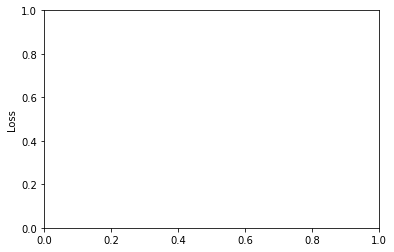

In [10]:
hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

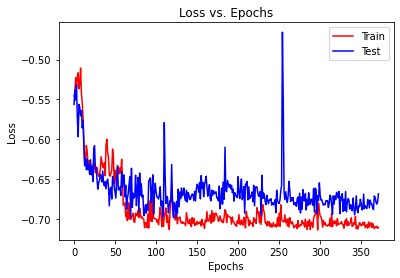

In [11]:
plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()
# plt.savefig('loss_plot.png')hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])


In [70]:
model.save_weights(checkpoint_path)

In [10]:
checkpoint_path = "./Affinecheck/0630_cp.ckpt"
model.load_weights(checkpoint_path)

In [10]:
output = model.predict(sample_loader)

In [11]:
print(max_value)

3095.0


In [13]:
min_value = np.min(moved)
max_value = np.max(moved)
print(min_value)
print(max_value)

-3024.0
2472.2847


In [12]:
# Voxel Affine 저장 ###########
output = model.predict(sample_loader)
moved = output['moved']
moved = moved * (max_value - min_value) + min_value

In [32]:
f1model = Model(inputs=model.model.input, outputs=model.model.get_layer('theta').output)
theta_x = f1model.predict(sample_loader)

print(theta_x.shape)


(29, 12)


In [29]:
print(theta_x)

[[ 7.78829634e-01  7.62967542e-02  1.69676915e-03 -6.56091049e-03
  -2.06362065e-02  1.09538364e+00 -2.93954089e-02  6.47640452e-02
  -7.03190872e-03  7.60716349e-02  9.51799095e-01  1.54368971e-02]
 [ 1.77129805e-01  2.26626799e-01  6.50228858e-02 -4.35724370e-02
  -8.59811753e-02  9.51276600e-01  9.34514776e-03 -1.09853959e-02
  -1.52052883e-02  2.80921534e-02  8.42444956e-01 -1.10353325e-02]
 [ 3.26015472e-01  1.65806994e-01  3.52291279e-02 -1.57493986e-02
  -6.82247728e-02  9.75093663e-01  1.96411274e-03 -1.62105989e-02
  -1.01138614e-02  2.80348845e-02  8.67555082e-01 -3.96617316e-03]
 [-9.43936706e-02  1.29052386e-01  2.24648528e-02  6.87487721e-02
  -1.18548945e-01  9.52329874e-01  4.57733087e-02 -1.02766141e-01
  -1.26998536e-02 -3.86547260e-02  8.55477512e-01 -1.92336198e-02]
 [ 7.17561662e-01  5.25783062e-01  1.07085600e-01 -5.08798361e-01
  -1.00313596e-01  1.18139040e+00  1.88661031e-02  1.66223198e-01
   1.61988121e-02  1.72433667e-02  9.30940866e-01 -3.78035903e-02]
 [-3.

In [79]:
### Affine 된 GT들을 Nearest Neighborhood Interpolation 진행 ###
aaa = 1
for i in range (0, 39):
    filename = "./BTCV_Data/gt_affine/" + str(aaa) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.astype(np.float32)
        w, h, d = x.shape

        while(1):
            change = x
            ff = 0
            for i in range(1,w-1):
                for j in range(1,h-1):
                    for k in range(1, d):
                        buffer = float(x[i][j][k]) 
                        if (buffer.is_integer() is False):
                            ff += 1
                            #output = [abs(x[i][j][k]-x[i-1][j][k]), abs(x[i][j][k]-x[i+1][j][k]), abs(x[i][j][k]-x[i][j-1][k]), abs(x[i][j][k]-x[i][j+1][k]),
                            #          abs(x[i][j][k]-x[i][j][k-1]), abs(x[i][j][k]-x[i][j][k+1])] 
                            #output_ch = [x[i-1][j][k], x[i+1][j][k], x[i][j-1][k], x[i][j+1][k], x[i][j][k-1], x[i][j][k+1]] 
                            output = []
                            output_ch = []
                            if (float(x[i-1][j][k]).is_integer() is True):
                                output_ch.append(x[i-1][j][k])
                                output.append(abs(x[i][j][k]-x[i-1][j][k]))
                            if (float(x[i+1][j][k]).is_integer() is True):
                                output_ch.append(x[i+1][j][k])
                                output.append(abs(x[i][j][k]-x[i+1][j][k]))
                            if (float(x[i][j-1][k]).is_integer() is True):
                                output_ch.append(x[i][j-1][k])
                                output.append(abs(x[i][j][k]-x[i][j-1][k]))
                            if (float(x[i][j+1][k]).is_integer() is True):
                                output_ch.append(x[i][j+1][k])
                                output.append(abs(x[i][j][k]-x[i][j+1][k]))
                            if (float(x[i][j][k-1]).is_integer() is True):
                                output_ch.append(x[i][j][k-1])
                                output.append(abs(x[i][j][k]-x[i][j][k-1]))
                            if (k < d-1):
                                if (float(x[i][j][k+1]).is_integer() is True):
                                    output_ch.append(x[i][j][k+1])
                                    output.append(abs(x[i][j][k]-x[i+1][j][k+1]))

                            a = np.argmin(output)
                            change[i][j][k] = output_ch[a]


            x = change
            print(ff)
            if (ff==0):
                break


        savename = "./BTCV_Data/gt_change/" + str(aaa) + ".nii.gz"
        x_copy = nib.Nifti1Image(change, None) 
        nib.save(x_copy,savename)
        
    aaa += 1
         
            

46951
0
6887
0
11667
0
14537
0
27865
0
56714
0
20273
0
6821
0
29405
0
10129
0
17753
0
20340
0
10671
0
35939
0
14067
0
18202
0
23819
0
21335
0
52228
0
21556
0
59585
0
33186
0
21253
0
16105
0
13440
0
40488
0
20483
0
22099
0
6389
0


In [6]:
### Affine 된 GT들을 Nearest Neighborhood Interpolation 진행 ###
aaa = 1
for i in range (0, 39):
    filename = "./BTCV_Data/gt_voxelmorph_r1/" + str(aaa) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.astype(np.float32)
        w, h, d = x.shape

        while(1):
            change = x
            ff = 0
            for i in range(1,w-1):
                for j in range(1,h-1):
                    for k in range(1, d):
                        buffer = float(x[i][j][k]) 
                        if (buffer.is_integer() is False):
                            ff += 1
                            #output = [abs(x[i][j][k]-x[i-1][j][k]), abs(x[i][j][k]-x[i+1][j][k]), abs(x[i][j][k]-x[i][j-1][k]), abs(x[i][j][k]-x[i][j+1][k]),
                            #          abs(x[i][j][k]-x[i][j][k-1]), abs(x[i][j][k]-x[i][j][k+1])] 
                            #output_ch = [x[i-1][j][k], x[i+1][j][k], x[i][j-1][k], x[i][j+1][k], x[i][j][k-1], x[i][j][k+1]] 
                            output = []
                            output_ch = []
                            if (float(x[i-1][j][k]).is_integer() is True):
                                output_ch.append(x[i-1][j][k])
                                output.append(abs(x[i][j][k]-x[i-1][j][k]))
                            if (float(x[i+1][j][k]).is_integer() is True):
                                output_ch.append(x[i+1][j][k])
                                output.append(abs(x[i][j][k]-x[i+1][j][k]))
                            if (float(x[i][j-1][k]).is_integer() is True):
                                output_ch.append(x[i][j-1][k])
                                output.append(abs(x[i][j][k]-x[i][j-1][k]))
                            if (float(x[i][j+1][k]).is_integer() is True):
                                output_ch.append(x[i][j+1][k])
                                output.append(abs(x[i][j][k]-x[i][j+1][k]))
                            if (float(x[i][j][k-1]).is_integer() is True):
                                output_ch.append(x[i][j][k-1])
                                output.append(abs(x[i][j][k]-x[i][j][k-1]))
                            if (k < d-1):
                                if (float(x[i][j][k+1]).is_integer() is True):
                                    output_ch.append(x[i][j][k+1])
                                    output.append(abs(x[i][j][k]-x[i+1][j][k+1]))

                            a = np.argmin(output)
                            change[i][j][k] = output_ch[a]


            x = change
            print(ff)
            if (ff==0):
                break


        savename = "./BTCV_Data/gt_change_vox_r1/" + str(aaa) + ".nii.gz"
        x_copy = nib.Nifti1Image(change, None) 
        nib.save(x_copy,savename)
        
    aaa += 1
         
            

39662
0
5259
0
6482
0
22449
0
22136
0
73404
0
25133
0
8954
0
76138
0
18733
0
13866
0
82020
0
10557
0
31501
0
15750
0
39262
0
79475
0
65092
0
65290
0
19339
0
79196
0
33656
0
64375
0
10551
0
64693
0
32661
0
67969
0
56703
0
6986
0


In [52]:
aaa = 3.45
aaaa = 6.000

if(aaa.is_integer()):
    print("aaaa")

In [38]:
a = [0.5, 0.4, 7, 0.1]
print(a[np.argmin(a)])

0.1


In [18]:
# Affine GT 만들기! 파일 불러와서 한번에 다 처리!##########
a = 1
j = 0
for i in range (0, 39):
    filename = "./BTCV_Data/gt_resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.astype(np.float32)
        x = x.swapaxes(0,2)
        print(x.shape)
        d,h,w = x.shape
        x = np.expand_dims(x,axis=0)
        x = np.expand_dims(x,axis=-1)

        grid = regular_grid_3d(d,h,w)
        nb = 1
#         print(theta_x[j][1])
        theta = tf.reshape(theta_x[j], [nb,3,4])

        grid_new = grid_transform_3d(theta[0], grid)
        grid_new = tf.clip_by_value(grid_new, -1, 1)


        moved = grid_sample_3d(x, grid_new)
        
        x = np.squeeze(moved[0]) 
        print(x.shape)
        
        d,h,w = x.shape
        x_copy = x.copy()
        
        x_copy = x_copy.swapaxes(0,2)
        print(a, ":", x_copy.shape )
        savename = "./BTCV_Data/gt_affine/" + str(a) + ".nii.gz"
        x_copy = nib.Nifti1Image(x_copy, None) 
        nib.save(x_copy,savename)
        
        j += 1
        
    a += 1


(64, 128, 128)
(64, 128, 128)
1 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
2 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
3 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
4 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
5 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
6 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
7 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
8 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
9 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
10 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
21 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
22 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
23 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
24 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
25 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
26 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
27 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
28 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
29 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
30 : (128, 128, 64)
(64, 128,

In [126]:
result = model.evaluate(sample_loader)

1/1 [==============================] - 0s 962us/step - loss: -0.3995


In [15]:
min_value = -3024.0
max_value = 3095.0

output = model.predict(sample_loader)
moved = output['moved']
moved = (moved * (max_value-min_value)) + min_value
print(np.min(moved))
print(np.max(moved))

print(moved.shape)
moved = np.squeeze(moved)

a = 1
j = 0
for i in range (0, 40):
    filename = "./BTCV_Data/1resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        
        savename = "./BTCV_Data/4affine_exis/" + str(a) + ".nii.gz"
        vox = moved[j]
        print(vox.shape)
#         vox = vox.swapaxes(0,2)
        x_copy = nib.Nifti1Image(vox, None) 
        nib.save(x_copy,savename)
        print(a)
        j += 1
        
    a += 1

-3024.0
2472.2847
(29, 64, 128, 128, 1)
(64, 128, 128)
1
(64, 128, 128)
2
(64, 128, 128)
3
(64, 128, 128)
4
(64, 128, 128)
5
(64, 128, 128)
6
(64, 128, 128)
7
(64, 128, 128)
8
(64, 128, 128)
9
(64, 128, 128)
10
(64, 128, 128)
21
(64, 128, 128)
22
(64, 128, 128)
23
(64, 128, 128)
24
(64, 128, 128)
25
(64, 128, 128)
26
(64, 128, 128)
27
(64, 128, 128)
28
(64, 128, 128)
29
(64, 128, 128)
30
(64, 128, 128)
31
(64, 128, 128)
32
(64, 128, 128)
33
(64, 128, 128)
34
(64, 128, 128)
35
(64, 128, 128)
36
(64, 128, 128)
37
(64, 128, 128)
38
(64, 128, 128)
39


IndexError: index 29 is out of bounds for axis 0 with size 29

In [79]:
theta.shape

TensorShape([1, 3, 4])

In [69]:
model.summary()

Model: "AffineNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
static (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
moving (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
concatenate_3 (Concatenate)     (None, 64, 128, 128, 0           static[0][0]                     
                                                                 moving[0][0]                     
__________________________________________________________________________________________________
conv3d_12 (Conv3D)              (None, 32, 64, 64, 1 880         concatenate_3[0][0]      